# GLM-5.3-Flash on 4x CMP 170HX (SM80) — 4card-tp4, vLLM

| Metric | Value |
|---|---|
| Decode, C1 (median of 5 reps) | **56.4 tok/s** (peak 56.9) |
| Best aggregate, C8 | **37.0 tok/s** (TP4 communication-bound) |
| Prefill | untested |
| TTFT | untested |

![C1/C8 and MTP sweep chart](../assets/charts/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu-sweep.png)

```bash
docker pull ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-20260903
```

Guide: [docs/models/glm-5.3-flash.md](../docs/models/glm-5.3-flash.md)


<video controls width="720" poster="../assets/video/glm53-vllm-sm80-motion/glm53-vllm-sm80-motion-poster.png">
  <source src="../assets/video/glm53-vllm-sm80-motion/glm53-vllm-sm80-motion-1080x1080.mp4" type="video/mp4">
</video>

[Square MP4](../assets/video/glm53-vllm-sm80-motion/glm53-vllm-sm80-motion-1080x1080.mp4) · [landscape](../assets/video/glm53-vllm-sm80-motion/glm53-vllm-sm80-motion-1920x1080.mp4) · [vertical](../assets/video/glm53-vllm-sm80-motion/glm53-vllm-sm80-motion-1080x1920.mp4) · [poster](../assets/video/glm53-vllm-sm80-motion/glm53-vllm-sm80-motion-poster.png)


In [1]:
# --- Status / replay guard ---
from pathlib import Path

EXPERIMENT = "2026-09-03-glm-5.3-flash-vllm-sm80-4gpu"
ENDPOINT_ENV_VAR = "GLM_VLLM_BENCH_ENDPOINT_URL"
LIVE = False  # Set True only when you intentionally provide a private endpoint.

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "results").exists():
    REPO_ROOT = Path("..")
RESULTS_DIR = REPO_ROOT / "results" / EXPERIMENT
assert RESULTS_DIR.exists(), f"Missing committed receipts: {RESULTS_DIR}"
print(f"experiment : {EXPERIMENT}")
print(f"LIVE       : {LIVE}")
print("status     : measured receipts replayed; no endpoint contacted")
print("endpoint   : read from environment only when LIVE=True")


experiment : 2026-09-03-glm-5.3-flash-vllm-sm80-4gpu
LIVE       : False
status     : measured receipts replayed; no endpoint contacted
endpoint   : read from environment only when LIVE=True


In [2]:
# --- Receipt helpers ---
import csv
import json
from IPython.display import Markdown, display

def load_json(name):
    with (RESULTS_DIR / name).open() as handle:
        return json.load(handle)

def render_table(headers, rows):
    lines = [
        "| " + " | ".join(headers) + " |",
        "|" + "|".join(["---"] * len(headers)) + "|",
    ]
    lines.extend("| " + " | ".join(str(value) for value in row) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

def write_summary_csv(rows, path):
    '''Write the structured chart source; never invent a measurement.'''
    path = Path(path)
    fieldnames = ["panel", "x_label", "x_value", "vllm_tok_s", "comparison_tok_s", "notes"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    return path

summary = load_json("summary.json")
mtpsweep = load_json("mtpsweep.json")
ladder = load_json("ladder.json")
attempts = load_json("attempts.json")
print("receipt files:", ", ".join(sorted(path.name for path in RESULTS_DIR.iterdir())))


receipt files: README.md, attempts.json, ladder.json, mtpsweep.json, run-manifest.json, summary.csv, summary.json


## 1. TL;DR

This is the first working vLLM lane for GLM-5.3-Flash on four CMP 170HX
(SM80) cards. The checkpoint is `wtdcode/GLM-5.3-Flash-AWQ-W4A16`, served
with TP4 and native MTP speculation. C1 is the useful headline: 56.4 tok/s
median, 56.9 tok/s peak. C8 aggregate falls to 37.0 tok/s because TP4
all-reduce crosses the PCIe fabric; PP4 + MTP is the next optimization.

The EXL3 values shown later are a contextual comparison from a separate
short-context protocol, not a merged or like-for-like score.


In [3]:
# --- Headline receipt ---
render_table(
    ["Measurement", "Value", "Evidence"],
    [
        ["C1 decode", f"{summary['headline']['decode_c1_median_tok_s']} tok/s median", "measured; 5 reps"],
        ["C1 peak", f"{summary['headline']['decode_c1_peak_tok_s']} tok/s", "measured; depth sweep"],
        ["C8 aggregate", f"{summary['headline']['aggregate_c8_tok_s']} tok/s", "measured; same TP4 boot"],
        ["Prefill / TTFT", "untested", "not in this receipt"],
    ],
)
print("model:", summary["model"]["name"], "| quant:", summary["model"]["quantization"])
print("runtime:", summary["runtime"]["engine"], "| topology:", summary["runtime"]["topology"])


| Measurement | Value | Evidence |
|---|---|---|
| C1 decode | 56.4 tok/s median | measured; 5 reps |
| C1 peak | 56.9 tok/s | measured; depth sweep |
| C8 aggregate | 37.0 tok/s | measured; same TP4 boot |
| Prefill / TTFT | untested | not in this receipt |

model: GLM-5.3-Flash | quant: AWQ W4A16 (compressed-tensors)
runtime: vLLM | topology: TP4


In [4]:
# --- Identity, pins, and fail-closed health gate ---
class FailClosedTelemetryGuard:
    def __init__(self, *, forced_airflow, power_limit_w, xid_ecc_events):
        self.forced_airflow = forced_airflow
        self.power_limit_w = power_limit_w
        self.xid_ecc_events = xid_ecc_events

    def assert_safe(self):
        assert self.forced_airflow, "Directed airflow is required for this passive card."
        assert self.power_limit_w <= 180, "Refusing a run above the club power cap."
        assert self.xid_ecc_events == 0, "Refusing a run with Xid/ECC events in the receipt."

health = summary["health"]
guard = FailClosedTelemetryGuard(
    forced_airflow=health["forced_airflow"],
    power_limit_w=summary["hardware"]["power_limit_w_per_card"],
    xid_ecc_events=health["xid_ecc_events"],
)
guard.assert_safe()
render_table(
    ["Pin", "Value"],
    [
        ["Checkpoint", f"{summary['model']['checkpoint']} @ {summary['model']['revision']}"],
        ["Cards", f"{summary['hardware']['cards']}x {summary['hardware']['card']} ({summary['hardware']['architecture']})"],
        ["Runtime", f"{summary['runtime']['engine']} · {summary['runtime']['fork']} · {summary['runtime']['branch']} @ {summary['runtime']['commit']}"],
        ["Image", summary["runtime"]["image"]],
        ["Topology", summary["runtime"]["topology"]],
        ["Quantization", summary["model"]["quantization"]],
        ["Max model length", f"{summary['protocol']['max_model_len']:,} configured; context stress {summary['protocol']['context_stress_test']}"],
        ["Power", f"{summary['hardware']['power_limit_w_per_card']} W/card"],
        ["Driver / kernel", f"{summary['hardware']['driver']} / {summary['hardware']['kernel']}"],
        ["MTP", "native, selected depth k=3"],
        ["Health", "0 Xid/ECC events; numeric peak temperature not captured"],
    ],
)


| Pin | Value |
|---|---|
| Checkpoint | wtdcode/GLM-5.3-Flash-AWQ-W4A16 @ abd7b07719111f137e1de8a0c1b7e01c11b74d1a |
| Cards | 4x NVIDIA CMP 170HX (SM80) |
| Runtime | vLLM · PixelML/sm80vllm · glm53-sm80 @ f6fbf3b854 |
| Image | ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-20260903 |
| Topology | TP4 |
| Quantization | AWQ W4A16 (compressed-tensors) |
| Max model length | 524,288 configured; context stress untested |
| Power | 180 W/card |
| Driver / kernel | not recorded in this receipt / not recorded in this receipt |
| MTP | native, selected depth k=3 |
| Health | 0 Xid/ECC events; numeric peak temperature not captured |

## 2. Visible results

All values below come from the committed JSON/CSV receipts. Token rates are
completion tokens per wall-clock second. The C1 depth sweep used temperature
0.7, 512 output tokens, `ignore_eos`, and five repetitions; the first
repetition is retained as the cold reference. The concurrency ladder reports
aggregate throughput, so a C8 value is not a per-request rate.


In [5]:
# --- MTP depth sweep ---
render_table(
    ["num_speculative_tokens", "median tok/s", "peak tok/s", "cold rep tok/s"],
    [
        [row["num_speculative_tokens"], row["median_tok_s"], row["peak_tok_s"], row["cold_rep_tok_s"]]
        for row in mtpsweep["rows"]
    ],
)
print("selected:", mtpsweep["selection"])


| num_speculative_tokens | median tok/s | peak tok/s | cold rep tok/s |
|---|---|---|---|
| 2 | 51.1 | 54.7 | 38.7 |
| 3 | 56.4 | 56.9 | 41.0 |
| 5 | 47.1 | 52.3 | 35.0 |

selected: num_speculative_tokens=3


In [6]:
# --- Aggregate concurrency ladder ---
render_table(
    ["Concurrency", "vLLM TP4 + MTP-3 aggregate tok/s", "EXL3 contextual comparison"],
    [
        [f"C{row['concurrency']}", row["aggregate_tok_s"], row["comparison_exl3_tok_s"]]
        for row in ladder["rows"]
    ],
)
print(ladder["comparison_note"])


| Concurrency | vLLM TP4 + MTP-3 aggregate tok/s | EXL3 contextual comparison |
|---|---|---|
| C1 | 54.7 | 25.2 |
| C8 | 37.0 | 44.6 |

The EXL3 row uses its own published short-context protocol; values are context, not a like-for-like replacement.


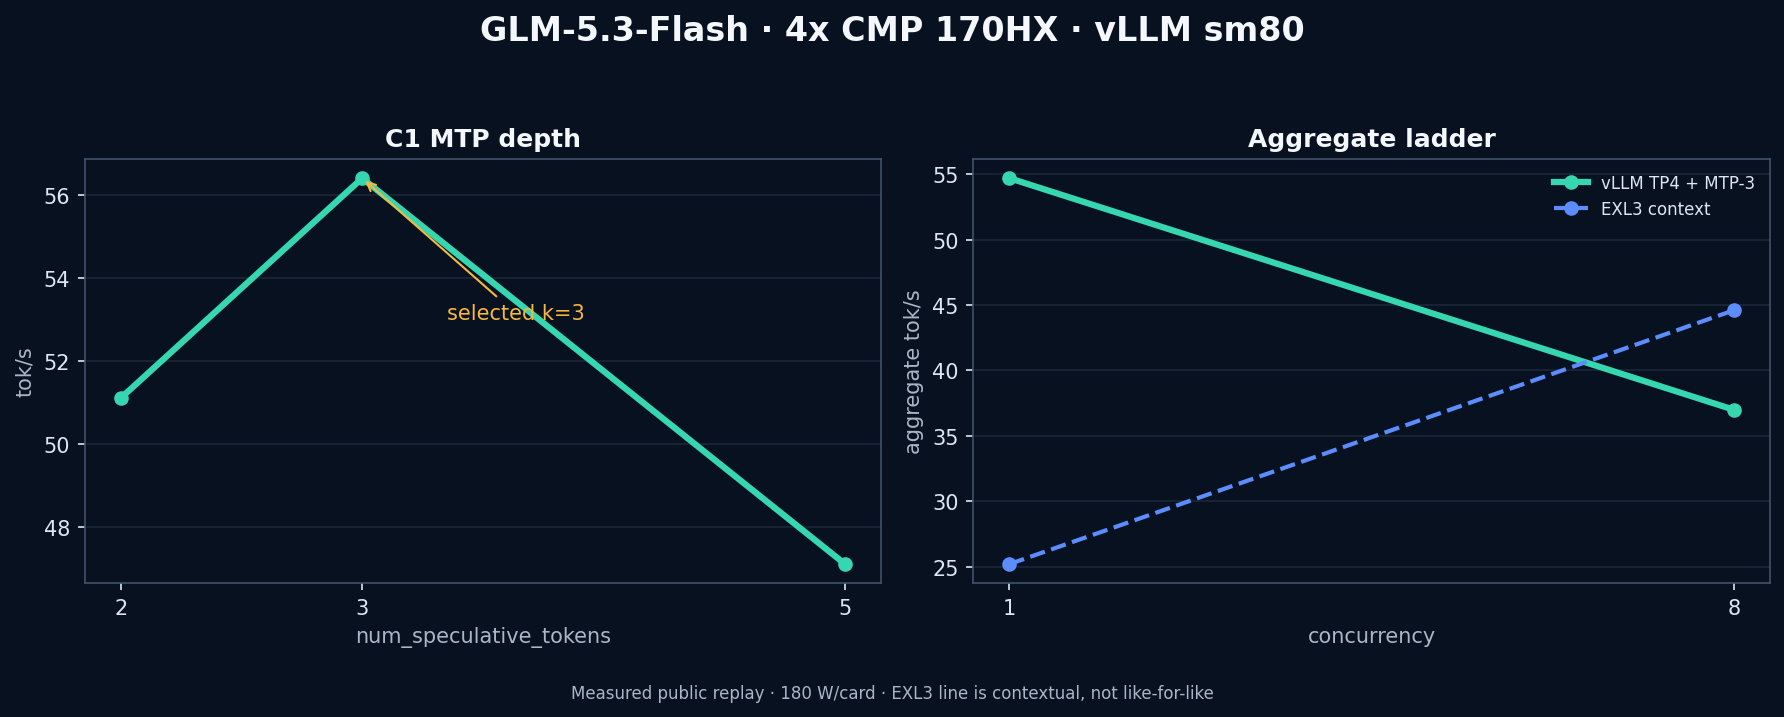

chart source: ../results/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu/summary.csv
chart outputs: ../assets/charts/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu-sweep.png ../assets/charts/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu-sweep.svg


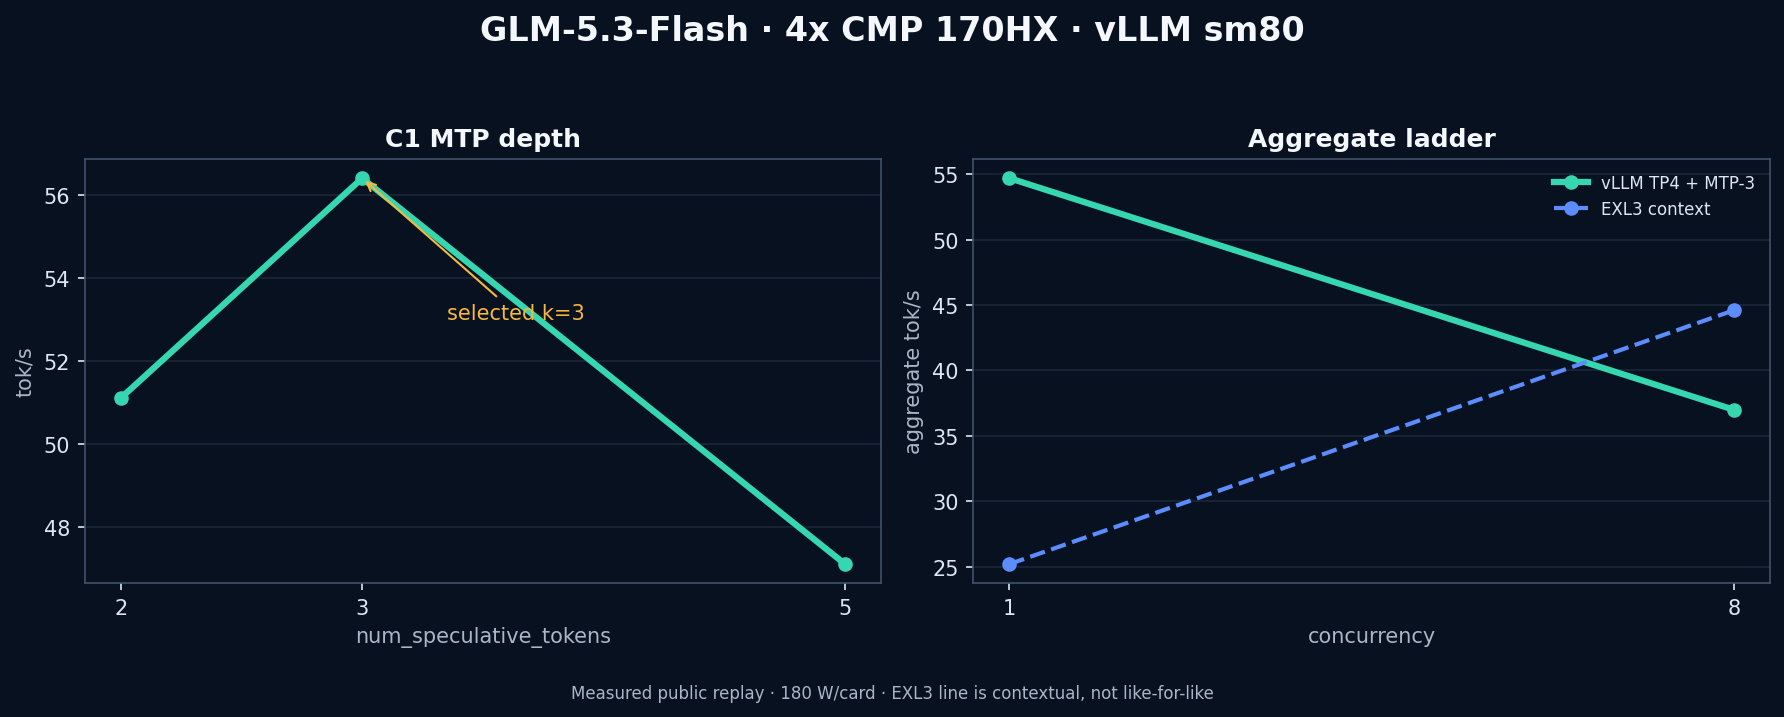

In [7]:
# --- Chart from the committed CSV source ---
import matplotlib.pyplot as plt

csv_path = RESULTS_DIR / "summary.csv"
with csv_path.open(newline="") as handle:
    chart_rows = list(csv.DictReader(handle))

mtp_rows = [row for row in chart_rows if row["panel"] == "mtp"]
agg_rows = [row for row in chart_rows if row["panel"] == "aggregate"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), dpi=150)
fig.patch.set_facecolor("#07111f")
for axis in axes:
    axis.set_facecolor("#07111f")
    axis.tick_params(colors="#dce7f5")
    for spine in axis.spines.values():
        spine.set_color("#41516a")
    axis.grid(axis="y", color="#2b3a50", alpha=0.55)

axes[0].plot([float(row["x_value"]) for row in mtp_rows], [float(row["vllm_tok_s"]) for row in mtp_rows], marker="o", color="#36d7b0", linewidth=3)
axes[0].set_title("C1 MTP depth", color="#f4f7fb", weight="bold")
axes[0].set_xlabel("num_speculative_tokens", color="#aab6c8")
axes[0].set_ylabel("tok/s", color="#aab6c8")
axes[0].set_xticks([float(row["x_value"]) for row in mtp_rows])
axes[0].annotate("selected k=3", xy=(3, 56.4), xytext=(3.35, 53), color="#f6b83f", arrowprops={"arrowstyle": "->", "color": "#f6b83f"})

axes[1].plot([float(row["x_value"]) for row in agg_rows], [float(row["vllm_tok_s"]) for row in agg_rows], marker="o", color="#36d7b0", linewidth=3, label="vLLM TP4 + MTP-3")
axes[1].plot([float(row["x_value"]) for row in agg_rows], [float(row["comparison_tok_s"]) for row in agg_rows], marker="o", color="#5c8dff", linewidth=2, linestyle="--", label="EXL3 context")
axes[1].set_title("Aggregate ladder", color="#f4f7fb", weight="bold")
axes[1].set_xlabel("concurrency", color="#aab6c8")
axes[1].set_ylabel("aggregate tok/s", color="#aab6c8")
axes[1].set_xticks([float(row["x_value"]) for row in agg_rows])
axes[1].legend(frameon=False, labelcolor="#dce7f5", fontsize=8, loc="best")
fig.suptitle("GLM-5.3-Flash · 4x CMP 170HX · vLLM sm80", color="#f4f7fb", fontsize=16, weight="bold")
fig.text(0.5, 0.01, "Measured public replay · 180 W/card · EXL3 line is contextual, not like-for-like", ha="center", color="#aab6c8", fontsize=8)
fig.tight_layout(rect=(0, 0.05, 1, 0.93))
chart_png = REPO_ROOT / "assets/charts/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu-sweep.png"
chart_svg = REPO_ROOT / "assets/charts/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu-sweep.svg"
fig.savefig(chart_png, facecolor=fig.get_facecolor(), bbox_inches="tight")
fig.savefig(chart_svg, facecolor=fig.get_facecolor(), bbox_inches="tight")
display(fig)
print("chart source:", csv_path)
print("chart outputs:", chart_png, chart_svg)


## 3. Reproduce

### Requirements

- Four NVIDIA CMP 170HX cards with directed airflow and the club's verified
  180 W/card benchmark cap.
- A CUDA/vLLM image built from the public `sm80vllm` fork at commit
  `f6fbf3b854`; the example image is
  `ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-20260903`.
- The pinned AWQ W4A16 checkpoint staged on local NVMe. A local copy avoids
  the long cold-start penalty from network storage.
- The measured path uses a PCIe-connected TP4 fabric; interconnect tuning is
  not part of this receipt.

Expected engine boot time and driver/kernel versions were not captured in
this receipt; they are shown as untested in the pins table.

### Configure

Set `<weights>` to the local checkpoint directory. Keep FlashInfer autotune
enabled when using MTP-3. The measured run used TP4, automatic KV mode,
`--max-model-len 524288`, and `--max-num-seqs 16`.

### Install

```bash
pip install -U huggingface_hub
hf download wtdcode/GLM-5.3-Flash-AWQ-W4A16   --revision abd7b07719111f137e1de8a0c1b7e01c11b74d1a   --local-dir <weights>
```

The receipt expects 24 files totaling 190,843,146,533 bytes.

### Start

```bash
docker pull ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-20260903
docker run -d --name <service-name> --gpus '"device=0,1,2,3"'   --shm-size 16g --ipc=host -p 127.0.0.1:18098:8000   -e HF_HUB_OFFLINE=1 -e VLLM_WORKER_MULTIPROC_METHOD=spawn   -e VLLM_ENGINE_READY_TIMEOUT_S=1800 -e VLLM_ENGINE_ITERATION_TIMEOUT_S=1800   -e NCCL_VERSION=2.28.3-1 -e TORCH_CUDA_ARCH_LIST=8.0 -e VLLM_TARGET_DEVICE=cuda   --mount type=bind,src=<weights>,dst=/model,readonly   ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-20260903   vllm serve /model --served-model-name glm-5.3-flash   --tensor-parallel-size 4 --max-model-len 524288 --gpu-memory-utilization 0.92   --max-num-seqs 16 --max-num-batched-tokens 8192 --enable-prefix-caching   --disable-custom-all-reduce   --compilation-config '{"cudagraph_mode":"FULL_AND_PIECEWISE","cudagraph_capture_sizes":[1,2,4,8,16],"max_cudagraph_capture_size":16}'   --speculative-config '{"method":"mtp","num_speculative_tokens":3}'
```

### Benchmark

Use the OpenAI-compatible `/v1/chat/completions` route on loopback. Count
tokens from the final `usage.completion_tokens` field, warm the engine once,
and record aggregate completion tokens per wall-clock second. The headline
receipt used five C1 repetitions and kept the first as the cold reference.

A minimal single-request check is:

```bash
curl -s http://127.0.0.1:18098/v1/chat/completions \
  -H 'Content-Type: application/json' \
  -d '{"model":"glm-5.3-flash","messages":[{"role":"user","content":"Reply with one word: ready"}],"max_tokens":8,"stream":false,"stream_options":{"include_usage":true}}'
```



In [8]:
# --- Reproduction preflight and immutable pins ---
assert summary["protocol"]["token_accounting"] == "final usage.completion_tokens"
assert summary["protocol"]["context_stress_test"] == "untested"
assert summary["runtime"]["topology"] == "TP4"
print("preflight: PASS (airflow, 180 W/card cap, zero Xid/ECC events)")
print("checkpoint bytes:", summary["model"]["bytes"])
print("image:", summary["runtime"]["image"])
print("MTP sweep rows:", len(mtpsweep["rows"]), "| ladder rows:", len(ladder["rows"]))


preflight: PASS (airflow, 180 W/card cap, zero Xid/ECC events)
checkpoint bytes: 190843146533
image: ghcr.io/pixelml/club-170hx:vllm-glm53-sm80-20260903
MTP sweep rows: 3 | ladder rows: 2


In [9]:
# --- Attempt log ---
render_table(
    ["Attempt", "Status", "Finding", "Resolution"],
    [[row["attempt"], row["status"], row["finding"], row["resolution"]] for row in attempts["rows"]],
)


| Attempt | Status | Finding | Resolution |
|---|---|---|---|
| 1 | fixed | Missing vendored SM80 patch in the image build | Added the attributed overlay from the SM80 enablement branch. |
| 2 | fixed | rustc was off PATH during the image build | Removed the CARGO_HOME override that hid rustup binaries. |
| 3 | fixed | GPU-dependent model import ran inside the driver-free image gate | Moved GPU-dependent imports to a post-build GPU gate. |
| 4 | unsafe combination | --no-enable-flashinfer-autotune with MTP-3 crashes engine startup | Measured recipe leaves FlashInfer autotune enabled. |
| 5 | blocked | PP4 plus MTP exhausted the last pipeline rank | Requires a PP-aware MTP patch; no claim of completion. |
| 6 | rejected | FP8 KV cache and block size 256 hit a Triton MLA backend limitation | Kept the runtime's automatic KV mode. |

<details>
<summary>4. Appendix</summary>

### What is measured

- C1 MTP depth sweep: k=2, 3, and 5, five repetitions per depth.
- TP4 aggregate ladder: C1 and C8 on the same boot.
- 0 Xid/ECC events were recorded; the receipt does not contain a numeric
  peak-temperature sample, so no peak temperature is claimed here.

### Limitations and next work

- Prefill and TTFT are untested in this notebook.
- C8 is communication-bound on TP4 over the PCIe fabric. PP4 + MTP is the
  next optimization and was not ported in this run.
- The EXL3 values in the chart and table use a separate short-context
  protocol and are included only as context.
- Do not combine `--no-enable-flashinfer-autotune` with MTP-3; the attempt
  log records that unsafe startup combination.

### Public artifacts

- [Result card](../results/2026-09-03-glm-5.3-flash-vllm-sm80-4gpu/README.md)
- [Model guide](../docs/models/glm-5.3-flash.md)
- [Benchmark matrix](../docs/BENCHMARKS.md)
- [Motion source](../assets/video/glm53-vllm-sm80-motion/README.md)


</details>

In [10]:
# --- Editable OpenAI-compatible request ---
import os

prompt = "Give a one-sentence explanation of why C8 aggregate throughput is lower than C1 on this TP4 run."
request = {
    "model": "glm-5.3-flash",
    "messages": [{"role": "user", "content": prompt}],
    "temperature": 0.0,
    "max_tokens": 128,
    "stream": False,
    "stream_options": {"include_usage": True},
}

if LIVE:
    import requests
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"Set {ENDPOINT_ENV_VAR}; refusing an implicit endpoint")
    response = requests.post(endpoint.rstrip("/") + "/v1/chat/completions", json=request, timeout=180)
    response.raise_for_status()
    completion = response.json()
    usage = completion.get("usage", {})
    if usage.get("completion_tokens") is None:
        raise RuntimeError("Missing final usage.completion_tokens; refusing to report speed")
else:
    completion = {
        "choices": [{"message": {"content": "TP4 all-reduce traffic is paid across the PCIe fabric at every layer."}}],
        "usage": {"prompt_tokens": 34, "completion_tokens": 18, "total_tokens": 52},
    }
    usage = completion["usage"]

print(completion["choices"][0]["message"]["content"])
print("replay final usage.completion_tokens:", usage["completion_tokens"])
print("To run live, set", ENDPOINT_ENV_VAR, "and change LIVE=True.")


TP4 all-reduce traffic is paid across the PCIe fabric at every layer.
replay final usage.completion_tokens: 18
To run live, set GLM_VLLM_BENCH_ENDPOINT_URL and change LIVE=True.
